# 05 — Exploratory Data Analysis
### KKBox Churn Prediction
Load `merged_features.csv` and visualize patterns that explain churn.
Every plot has a markdown cell below it explaining what to look for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Global style ────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

CHURN_COLORS = {0: '#4C9BE8', 1: '#E8604C'}   # blue = renewed, red = churned
CHURN_LABELS = {0: 'Renewed (0)', 1: 'Churned (1)'}

# ── Load data ───────────────────────────────────────────────────
df = pd.read_csv(r'D:\PROJECTS\customer-churn-prediction\merged_features.csv')
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["is_churn"].mean():.2%}')
df.head()

Shape: (970960, 47)
Churn rate: 8.99%


,is_churn,age,registration_year,last_price,last_paid,last_auto_renew,last_cancel,total_cancels,num_transactions,last_expire,...,city_nan,gender_female,gender_male,gender_nan,registered_via_3.0,registered_via_4.0,registered_via_7.0,registered_via_9.0,registered_via_13.0,registered_via_nan
0,1,28.0,2013.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,False,False,True,False,True,False,False,False,False,False
1,1,20.0,2013.0,180.0,180.0,0.0,0.0,0.0,1.0,2017-04-11,...,False,False,True,False,True,False,False,False,False,False
2,1,18.0,2013.0,300.0,300.0,0.0,0.0,0.0,2.0,2017-06-15,...,False,False,True,False,True,False,False,False,False,False
3,1,0.0,2014.0,149.0,149.0,1.0,0.0,0.0,10.0,2018-01-08,...,False,False,False,True,False,False,True,False,False,False
4,1,35.0,2014.0,99.0,99.0,1.0,0.0,1.0,8.0,2017-09-18,...,False,True,False,False,False,False,True,False,False,False


---
## 1. Churn Distribution (Class Balance)
**What to look for:** Confirms the class imbalance. The churned bar should be ~6–7x shorter than the renewed bar. This is why we use ROC-AUC and `scale_pos_weight` in modeling, not accuracy.

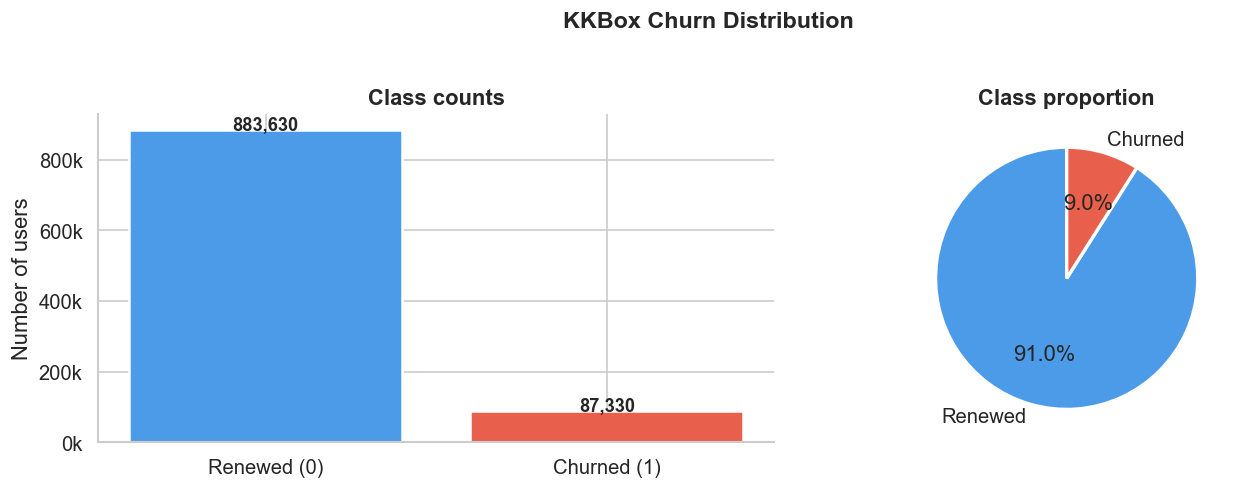

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
counts = df['is_churn'].value_counts().sort_index()
bars = axes[0].bar(
    ['Renewed (0)', 'Churned (1)'],
    counts.values,
    color=[CHURN_COLORS[0], CHURN_COLORS[1]],
    edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class counts', fontweight='bold')
axes[0].set_ylabel('Number of users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Percentage pie
axes[1].pie(
    counts.values,
    labels=['Renewed', 'Churned'],
    colors=[CHURN_COLORS[0], CHURN_COLORS[1]],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Class proportion', fontweight='bold')

plt.suptitle('KKBox Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_churn_distribution.png', bbox_inches='tight')
plt.show()

---
## 2. Correlation Heatmap (Top Features vs is_churn)
**What to look for:**
- `last_auto_renew`: strong negative correlation with churn — users who auto-renew almost never churn.
- `last_cancel`: positive correlation — cancellations predict churn.
- `active_days`, `total_secs`: negative — engaged users don't leave.
- Features with correlation near 0 = useless alone (but LightGBM can still combine them).

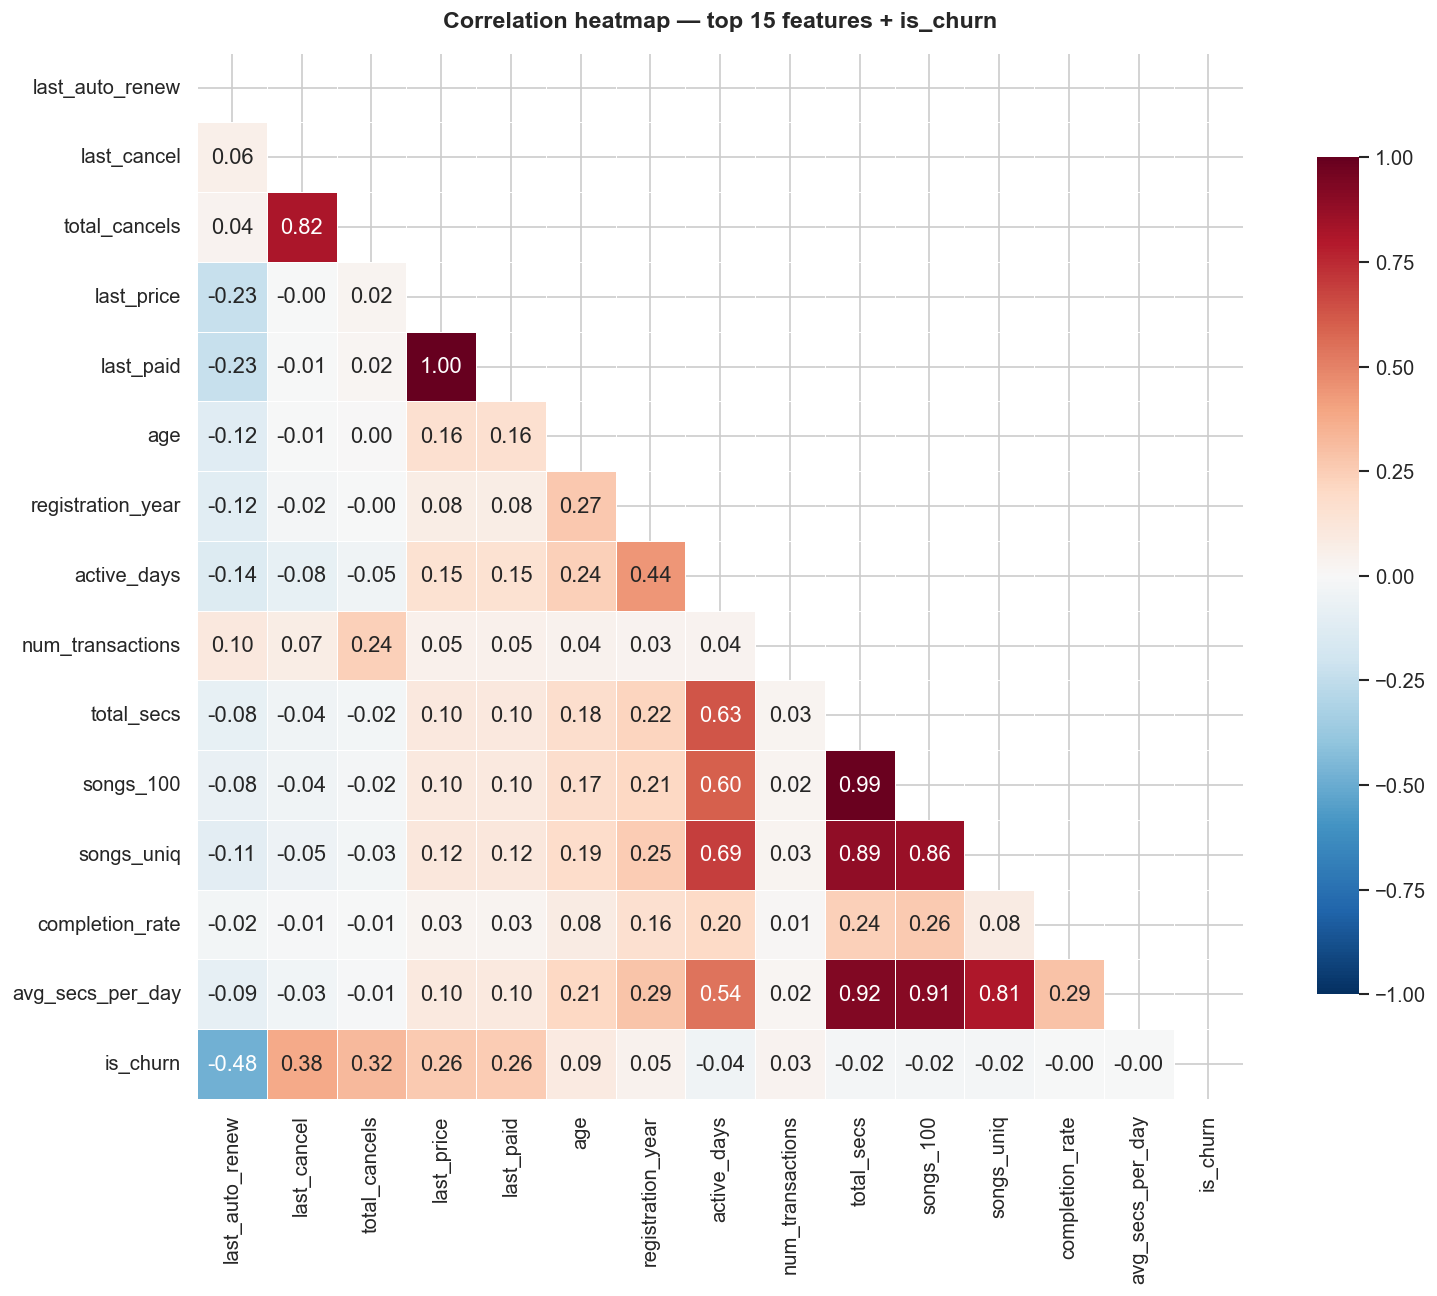


Top 15 features by |correlation| with is_churn:
last_auto_renew      0.480287
last_cancel          0.377529
total_cancels        0.324690
last_price           0.259721
last_paid            0.257357
age                  0.088513
registration_year    0.045558
active_days          0.044684
num_transactions     0.032999
total_secs           0.019582
songs_100            0.018765
songs_uniq           0.017574
completion_rate      0.002939
avg_secs_per_day     0.001414


In [3]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Top 15 features correlated with is_churn (excluding one-hot encoded dummies)
core_features = [c for c in numeric_cols if not any(
    c.startswith(prefix) for prefix in ['city_', 'gender_', 'registered_via_']
)]

corr_with_churn = (
    df[core_features].corr()['is_churn']
    .drop('is_churn')
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

top_features = corr_with_churn.index.tolist() + ['is_churn']
corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation heatmap — top 15 features + is_churn', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\nTop 15 features by |correlation| with is_churn:')
print(corr_with_churn.to_string())

---
## 3. Boxplots — Key Numeric Features by Churn
**What to look for:**
- If the median box for Churned vs Renewed doesn't overlap → strong feature.
- Wide boxes = high variance (noisy feature).
- Many outliers = check if they're real or data issues.
- `total_secs`: churners likely listen much less.
- `last_price`: did churners pay more? Price sensitivity = churn.

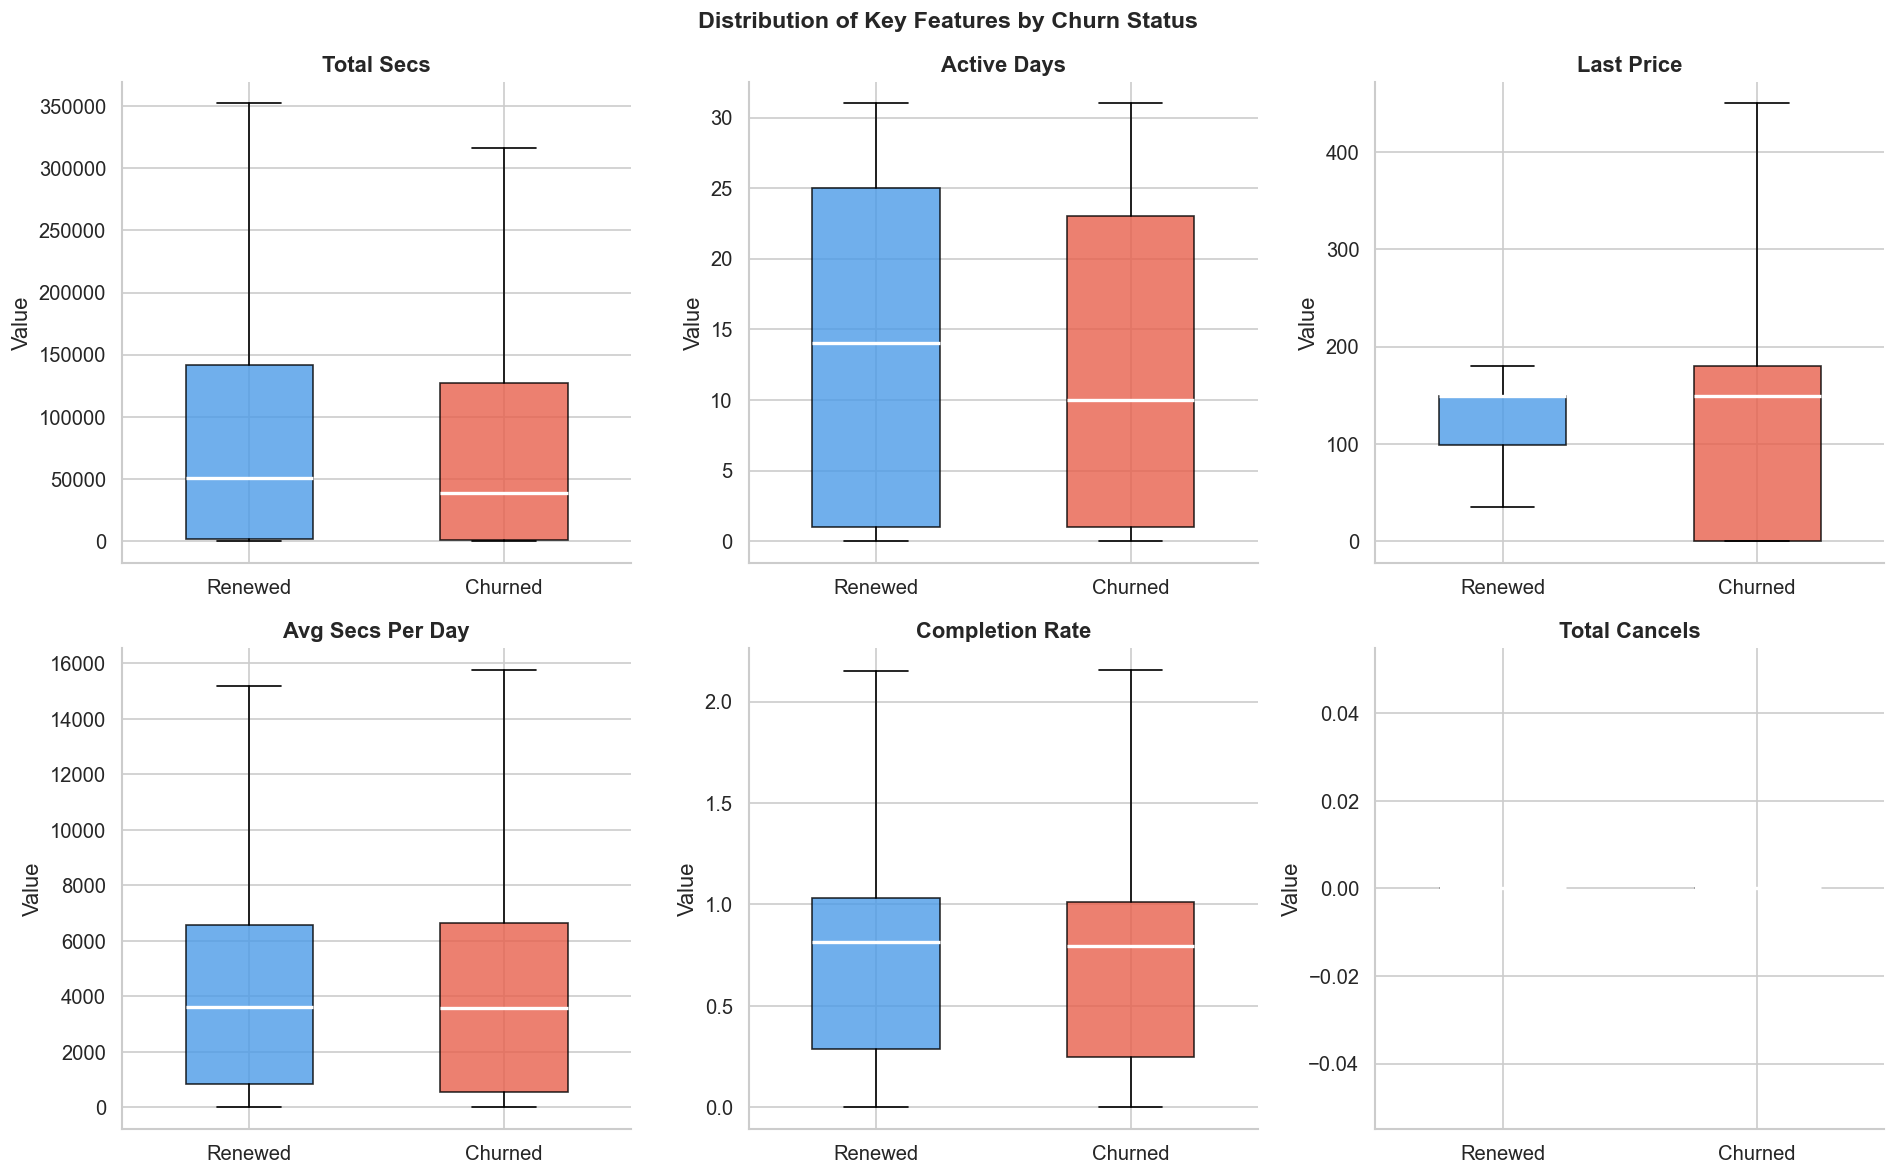

In [4]:
boxplot_features = [
    'total_secs', 'active_days', 'last_price',
    'avg_secs_per_day', 'completion_rate', 'total_cancels'
]
# Keep only features that actually exist in df
boxplot_features = [f for f in boxplot_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(boxplot_features):
    ax = axes[i]
    data_to_plot = [
        df.loc[df['is_churn'] == 0, feat].dropna(),
        df.loc[df['is_churn'] == 1, feat].dropna()
    ]
    bp = ax.boxplot(
        data_to_plot,
        patch_artist=True,
        showfliers=False,   # hide extreme outliers for readability
        widths=0.5,
        medianprops=dict(color='white', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], [CHURN_COLORS[0], CHURN_COLORS[1]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Renewed', 'Churned'])
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Value')

# Hide any unused subplots
for j in range(len(boxplot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Features by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_boxplots.png', bbox_inches='tight')
plt.show()

---
## 4. Pair Plot — Multi-feature Relationships
**What to look for:**
- Diagonal: KDE distribution of each feature — do churners cluster differently?
- Off-diagonal scatterplots: colored by churn. Clear color separation = useful feature combination.
- Example: `active_days` vs `total_secs` — churners likely cluster in the bottom-left (low on both).
- This is the most information-dense plot. Take 2–3 minutes to study each panel.

> **Note:** We sample 3,000 rows per class to keep rendering fast. The patterns are the same.

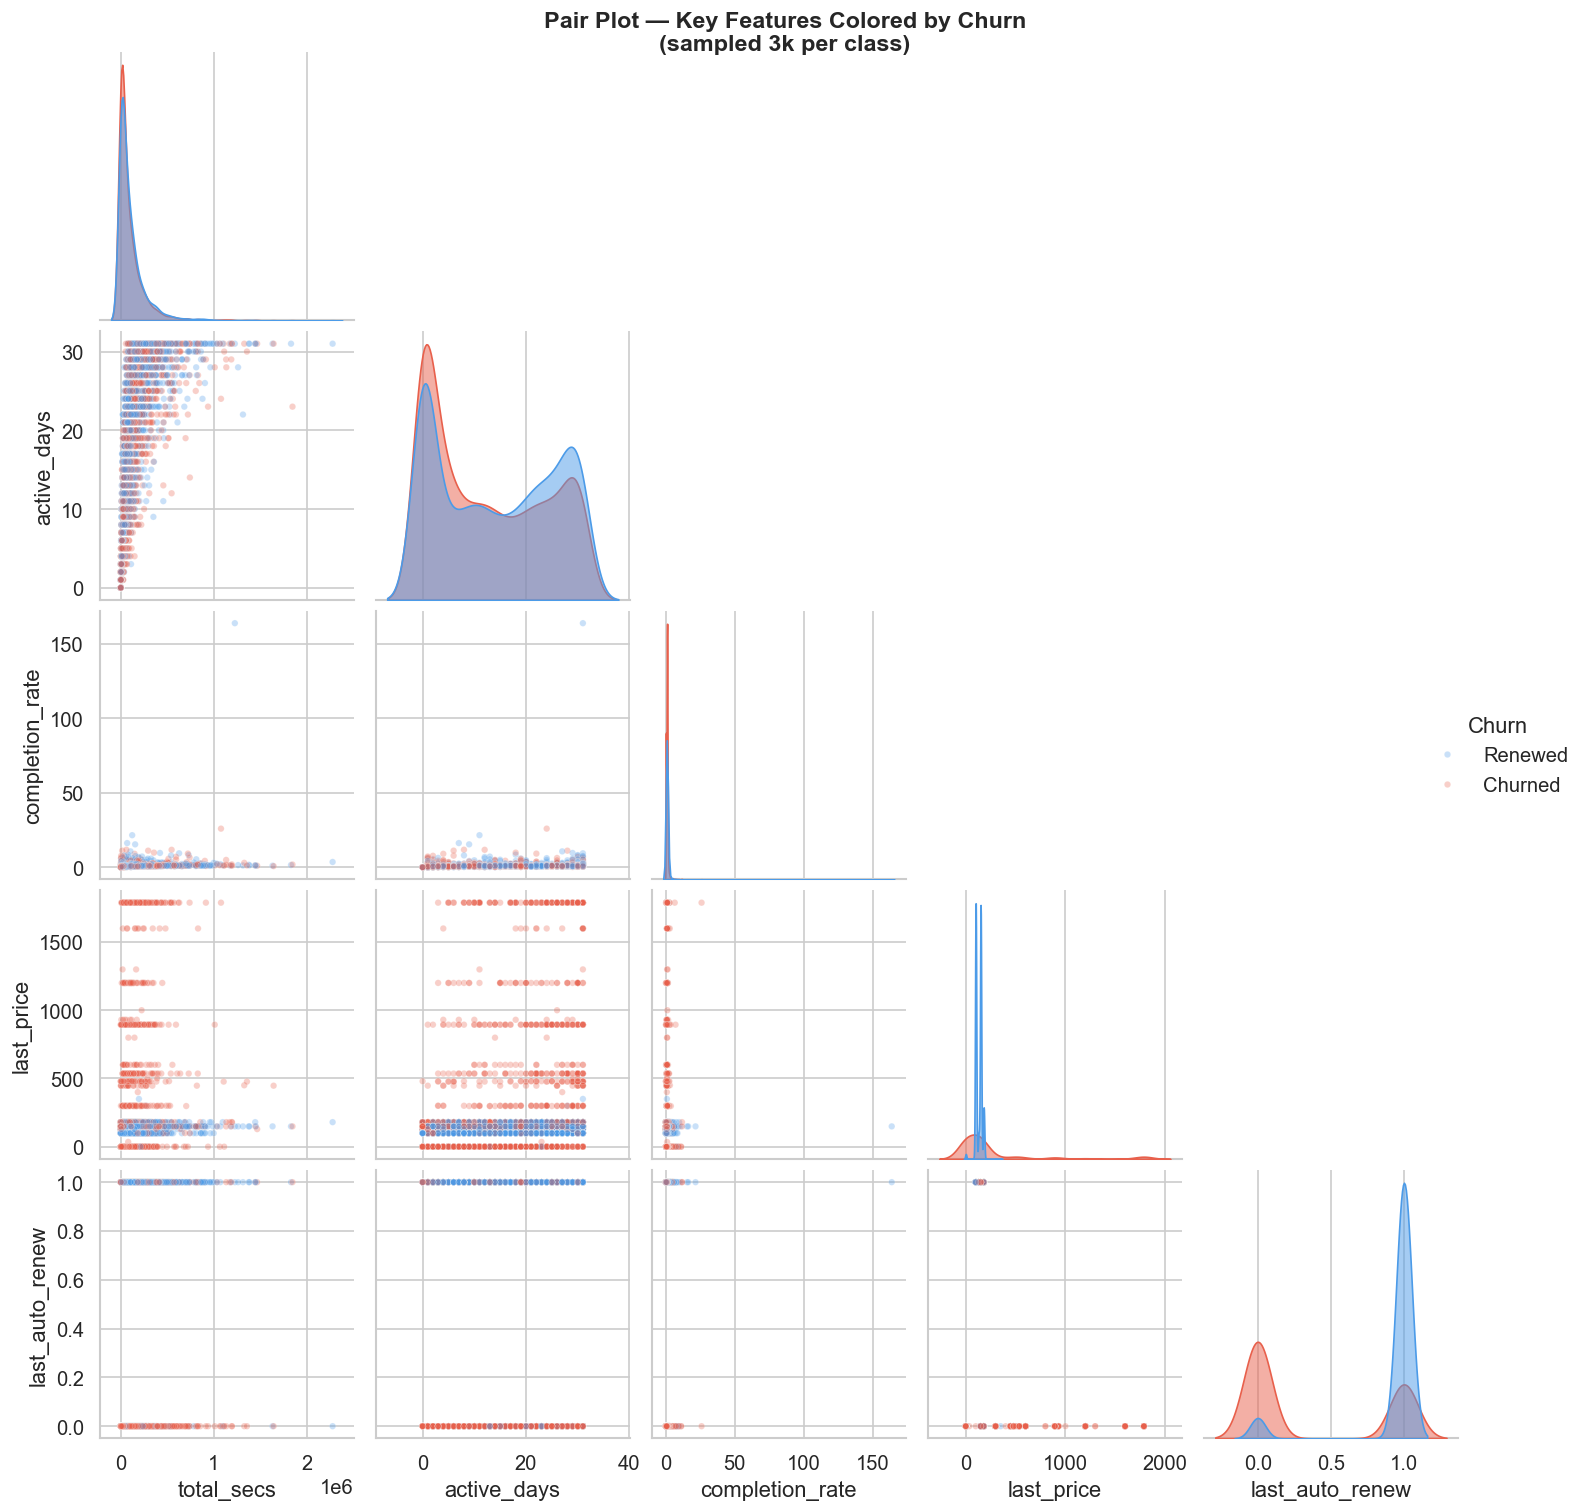

In [5]:
pair_features = [
    'total_secs', 'active_days', 'completion_rate',
    'last_price', 'last_auto_renew', 'is_churn'
]
pair_features = [f for f in pair_features if f in df.columns]

# Sample for speed (pair plots are slow with 100k+ rows)
sample_renewed = df[df['is_churn'] == 0].sample(3000, random_state=42)
sample_churned = df[df['is_churn'] == 1].sample(
    min(3000, df['is_churn'].sum()), random_state=42
)
df_sample = pd.concat([sample_renewed, sample_churned]).sample(frac=1, random_state=42)

g = sns.pairplot(
    df_sample[pair_features],
    hue='is_churn',
    palette=CHURN_COLORS,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15},
    diag_kws={'fill': True, 'alpha': 0.5},
    corner=True   # only lower triangle, faster
)
g.figure.suptitle(
    'Pair Plot — Key Features Colored by Churn\n(sampled 3k per class)',
    y=1.01, fontsize=14, fontweight='bold'
)

# Fix legend labels
legend = g._legend
if legend:
    legend.set_title('Churn')
    for text, label in zip(legend.texts, ['Renewed', 'Churned']):
        text.set_text(label)

plt.savefig('plot_04_pairplot.png', bbox_inches='tight')
plt.show()

---
## 5. Auto-Renew vs Churn Rate — The Strongest Signal
**What to look for:**
- Users with `last_auto_renew = 0` (manual renewal) will have dramatically higher churn.
- This is the #1 predictive feature in this dataset — a user who turns off auto-renew is signaling they're about to leave.
- The churn rate difference here will likely be 10x or more.

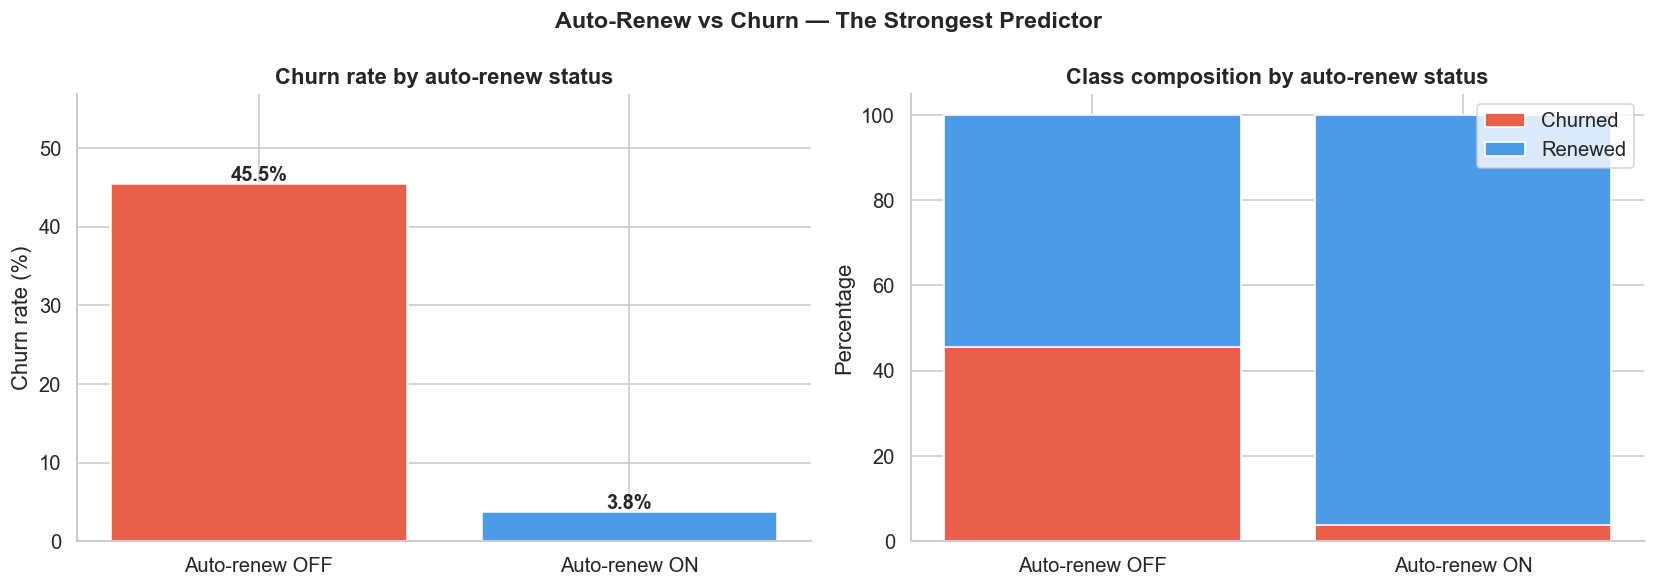

                  sum   count  churn_rate
Auto-renew OFF  54771  120276    0.455378
Auto-renew ON   32559  850684    0.038274


In [6]:
if 'last_auto_renew' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count of each group
    ar_churn = df.groupby('last_auto_renew')['is_churn'].agg(['sum', 'count'])
    ar_churn['churn_rate'] = ar_churn['sum'] / ar_churn['count']
    ar_churn.index = ['Auto-renew OFF', 'Auto-renew ON']

    # Bar: churn rate
    bars = axes[0].bar(
        ar_churn.index, ar_churn['churn_rate'] * 100,
        color=[CHURN_COLORS[1], CHURN_COLORS[0]],
        edgecolor='white', linewidth=1.5
    )
    for bar, val in zip(bars, ar_churn['churn_rate']):
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1%}', ha='center', fontsize=12, fontweight='bold'
        )
    axes[0].set_title('Churn rate by auto-renew status', fontweight='bold')
    axes[0].set_ylabel('Churn rate (%)')
    axes[0].set_ylim(0, ar_churn['churn_rate'].max() * 1.25 * 100)

    # Stacked bar: composition
    for idx, (label, row) in enumerate(ar_churn.iterrows()):
        churned_pct  = row['churn_rate'] * 100
        renewed_pct  = 100 - churned_pct
        axes[1].bar(label, churned_pct,  color=CHURN_COLORS[1], label='Churned'  if idx==0 else '')
        axes[1].bar(label, renewed_pct,  bottom=churned_pct, color=CHURN_COLORS[0], label='Renewed' if idx==0 else '')
    axes[1].set_title('Class composition by auto-renew status', fontweight='bold')
    axes[1].set_ylabel('Percentage')
    axes[1].legend()

    plt.suptitle('Auto-Renew vs Churn — The Strongest Predictor', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_05_autorenew_churn.png', bbox_inches='tight')
    plt.show()
    print(ar_churn)

---
## 6. KDE Plots — Feature Distributions by Churn
**What to look for:**
- KDE (Kernel Density Estimate) is a smooth histogram. Two peaks with little overlap = strong feature.
- `total_secs`: churners should peak lower (they listen less before leaving).
- `completion_rate`: churners may not finish songs — they're not engaged.
- `avg_secs_per_day`: behavioral intensity signal.
- If distributions overlap almost completely → feature won't help on its own.

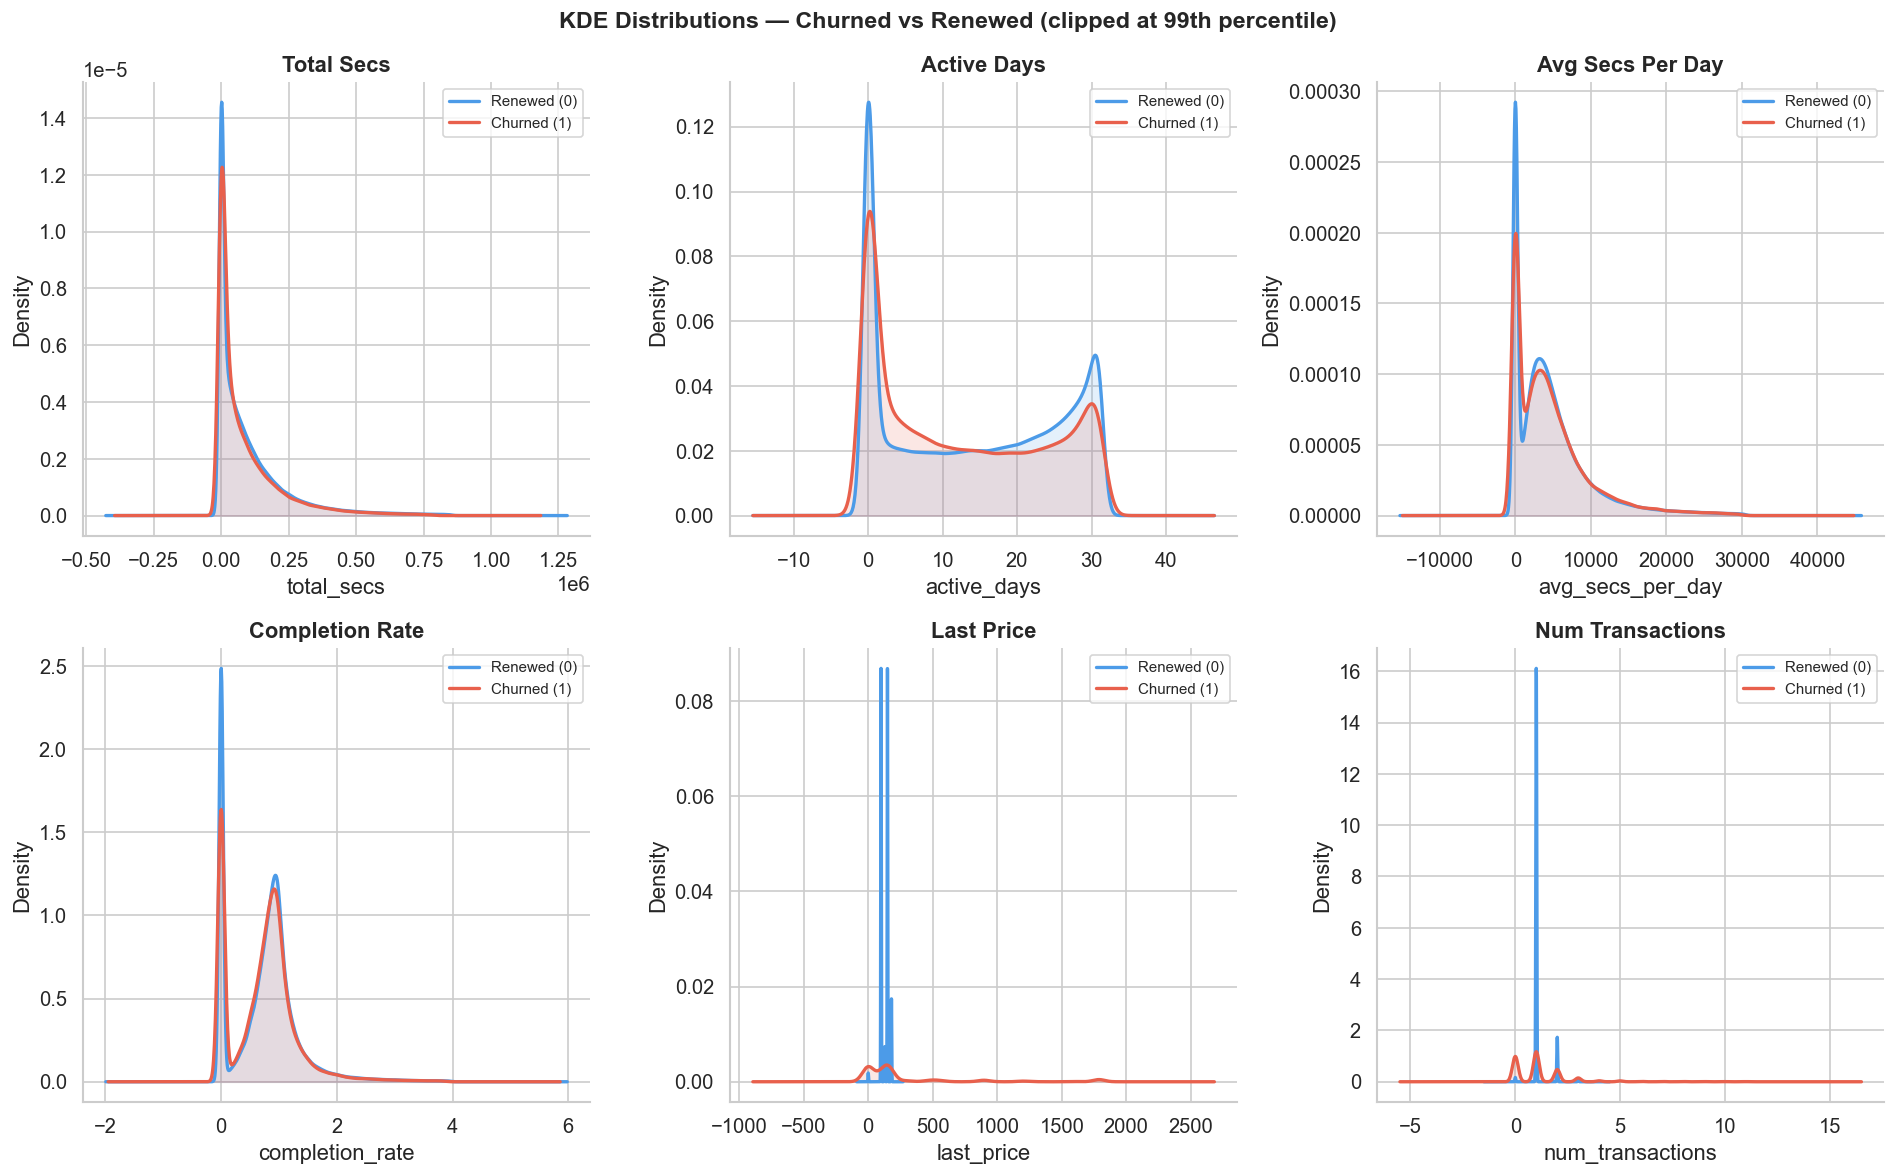

In [7]:
kde_features = [
    'total_secs', 'active_days', 'avg_secs_per_day',
    'completion_rate', 'last_price', 'num_transactions'
]
kde_features = [f for f in kde_features if f in df.columns]

n_cols = 3
n_rows = -(-len(kde_features) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(kde_features):
    ax = axes[i]
    for churn_val, color in CHURN_COLORS.items():
        subset = df.loc[df['is_churn'] == churn_val, feat].dropna()
        # Clip extreme outliers for KDE readability
        q99 = subset.quantile(0.99)
        subset = subset[subset <= q99]
        subset.plot.kde(
            ax=ax, label=CHURN_LABELS[churn_val],
            color=color, linewidth=2
        )
        ax.fill_between(
            ax.lines[-1].get_xdata(),
            ax.lines[-1].get_ydata(),
            alpha=0.15, color=color
        )
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

for j in range(len(kde_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('KDE Distributions — Churned vs Renewed (clipped at 99th percentile)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_kde_distributions.png', bbox_inches='tight')
plt.show()

---
## 7. Age Distribution by Churn
**What to look for:**
- Age column is cleaned to 10–80 only (rest are null/0).
- Users with `age = 0` (null/missing) are excluded from this plot.
- Common pattern: younger users (~18–25) churn more often — they're price-sensitive and platform-hop.
- Very old users (60+) may also churn more — lower tech adoption.
- The 25–40 demographic typically churns least.

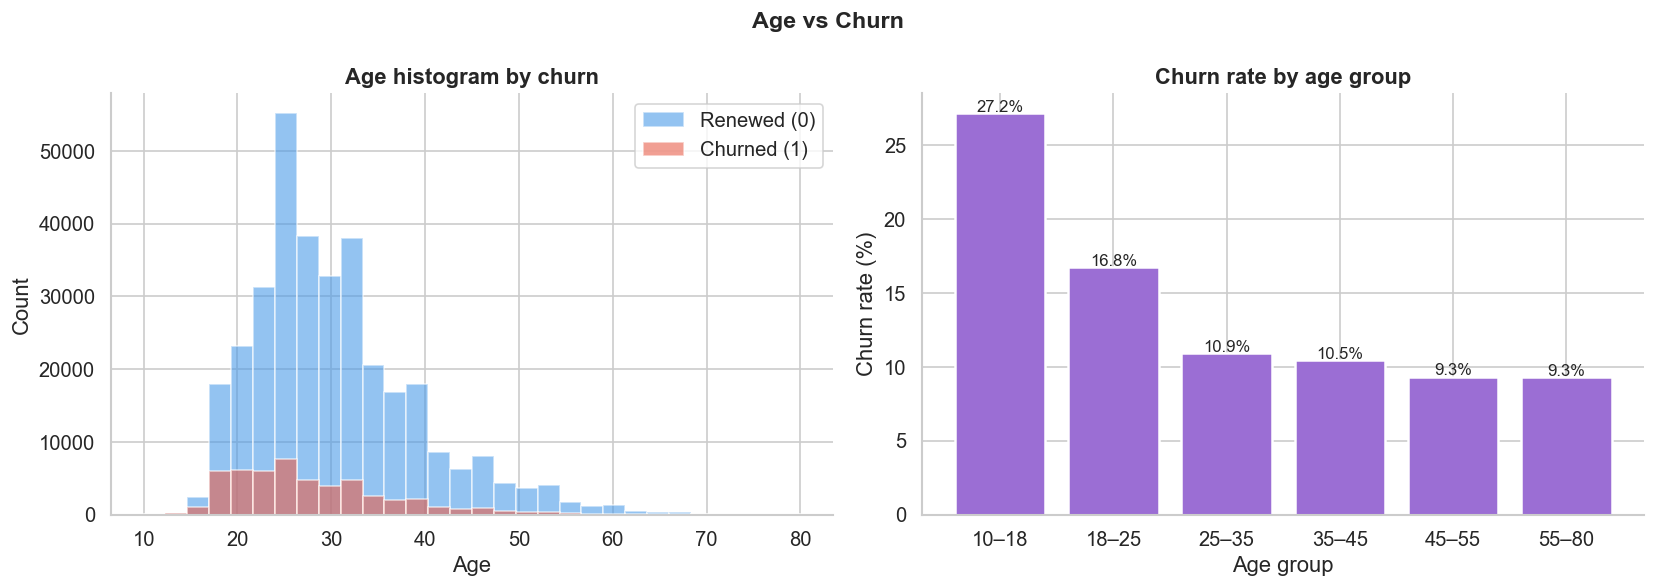

In [8]:
if 'age' in df.columns:
    df_age = df[(df['age'] > 0) & (df['age'].notna())].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    for churn_val, color in CHURN_COLORS.items():
        subset = df_age.loc[df_age['is_churn'] == churn_val, 'age']
        axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                     label=CHURN_LABELS[churn_val], edgecolor='white')
    axes[0].set_title('Age histogram by churn', fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # Churn rate by age group
    df_age['age_group'] = pd.cut(
        df_age['age'],
        bins=[10, 18, 25, 35, 45, 55, 80],
        labels=['10–18', '18–25', '25–35', '35–45', '45–55', '55–80']
    )
    churn_by_age = df_age.groupby('age_group')['is_churn'].mean() * 100
    bars = axes[1].bar(
        churn_by_age.index.astype(str),
        churn_by_age.values,
        color='#9B6ED4', edgecolor='white', linewidth=1.5
    )
    for bar, val in zip(bars, churn_by_age.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', fontsize=10)
    axes[1].set_title('Churn rate by age group', fontweight='bold')
    axes[1].set_xlabel('Age group')
    axes[1].set_ylabel('Churn rate (%)')

    plt.suptitle('Age vs Churn', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_07_age_churn.png', bbox_inches='tight')
    plt.show()

---
## 8. Number of Cancellations vs Churn
**What to look for:**
- Users who have cancelled multiple times in their history should churn at much higher rates.
- Even 1 cancel is a strong churn signal.
- This captures *behavioral history*, not just their last action.
- Clip at 5+ to avoid a long tail of rare events making the chart hard to read.

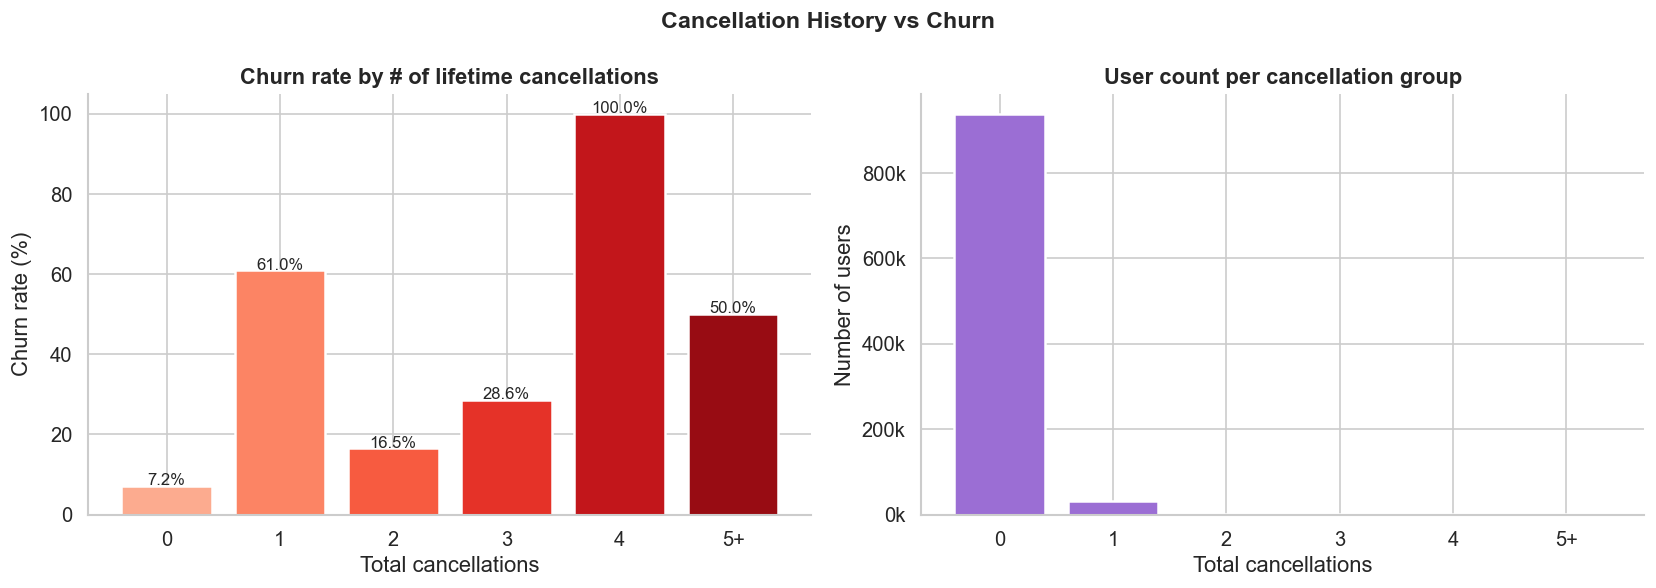

              churn_rate  user_count
cancel_group                        
0               7.228582      938635
1              60.958280       31807
2              16.496945         491
3              28.571429          21
4             100.000000           2
5+             50.000000           4


In [9]:
if 'total_cancels' in df.columns:
    df_cancel = df.copy()
    df_cancel['cancel_group'] = df_cancel['total_cancels'].clip(0, 5).astype(int).astype(str)
    df_cancel.loc[df_cancel['total_cancels'] >= 5, 'cancel_group'] = '5+'

    churn_by_cancel = df_cancel.groupby('cancel_group')['is_churn'].agg(['mean', 'count'])
    churn_by_cancel.columns = ['churn_rate', 'user_count']
    churn_by_cancel['churn_rate'] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Churn rate by cancel count
    bars = axes[0].bar(
        churn_by_cancel.index, churn_by_cancel['churn_rate'],
        color=plt.cm.Reds(np.linspace(0.3, 0.9, len(churn_by_cancel))),
        edgecolor='white', linewidth=1.5
    )
    for bar, val in zip(bars, churn_by_cancel['churn_rate']):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f'{val:.1f}%', ha='center', fontsize=10)
    axes[0].set_title('Churn rate by # of lifetime cancellations', fontweight='bold')
    axes[0].set_xlabel('Total cancellations')
    axes[0].set_ylabel('Churn rate (%)')

    # User count per group
    axes[1].bar(
        churn_by_cancel.index, churn_by_cancel['user_count'],
        color='#9B6ED4', edgecolor='white', linewidth=1.5
    )
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    axes[1].set_title('User count per cancellation group', fontweight='bold')
    axes[1].set_xlabel('Total cancellations')
    axes[1].set_ylabel('Number of users')

    plt.suptitle('Cancellation History vs Churn', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_08_cancels_churn.png', bbox_inches='tight')
    plt.show()
    print(churn_by_cancel)

---
## 9. Registration Year vs Churn Rate
**What to look for:**
- Older registration = loyal user = lower churn (loyalty effect).
- Very recent registrations may show high churn — users still deciding if they like the service.
- If a specific year has unusually high churn, that could indicate a pricing change or competitor launch that year.

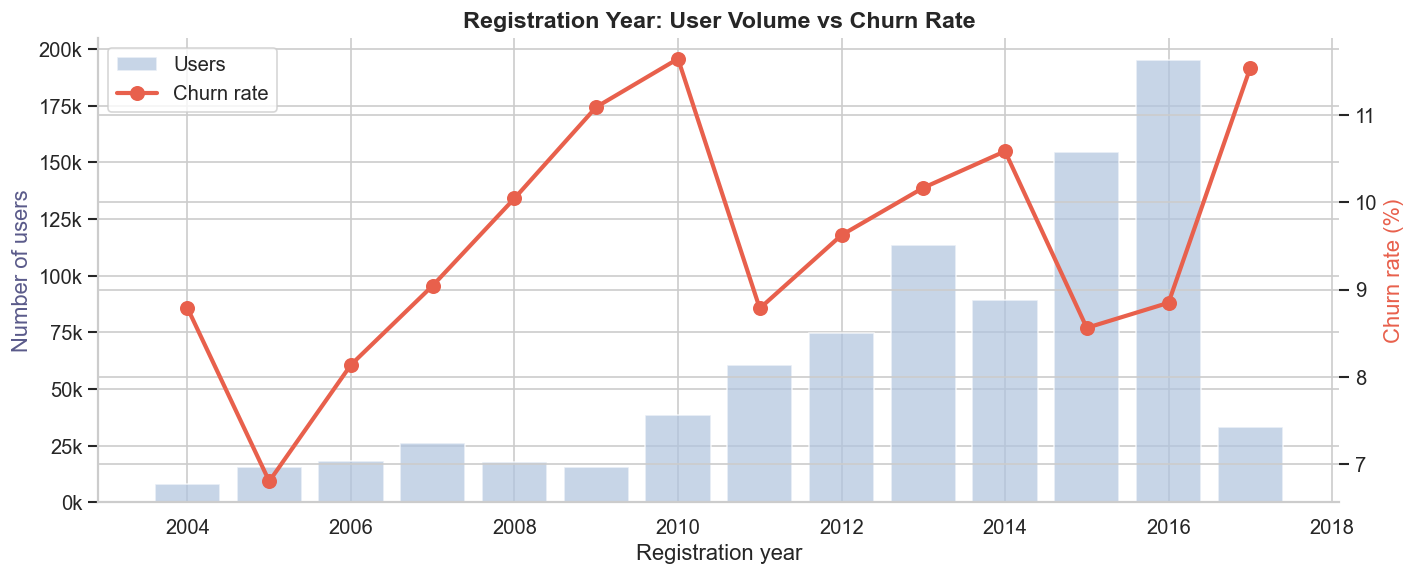

In [10]:
if 'registration_year' in df.columns:
    df_reg = df[df['registration_year'] > 2000].copy()  # remove 0/null encoded as 0

    churn_by_year = df_reg.groupby('registration_year')['is_churn'].agg(['mean', 'count'])
    churn_by_year.columns = ['churn_rate', 'user_count']

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()

    ax1.bar(churn_by_year.index, churn_by_year['user_count'],
            color='#B0C4DE', alpha=0.7, label='Users')
    ax2.plot(churn_by_year.index, churn_by_year['churn_rate'] * 100,
             color=CHURN_COLORS[1], marker='o', linewidth=2.5,
             markersize=8, label='Churn rate')

    ax1.set_xlabel('Registration year')
    ax1.set_ylabel('Number of users', color='#5A5A8A')
    ax2.set_ylabel('Churn rate (%)', color=CHURN_COLORS[1])
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    ax1.set_title('Registration Year: User Volume vs Churn Rate', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_09_reg_year_churn.png', bbox_inches='tight')
    plt.show()

---
## 10. Completion Rate vs Active Days — Scatter by Churn
**What to look for:**
- This 2D scatter is the clearest way to see behavioral segments.
- High active days + high completion rate = highly engaged user (almost never churns).
- Low active days + low completion rate = disengaged user (very likely to churn).
- If the two colors form distinct clusters here → these two features together are very powerful.
- Density contours are added to show where most users sit.

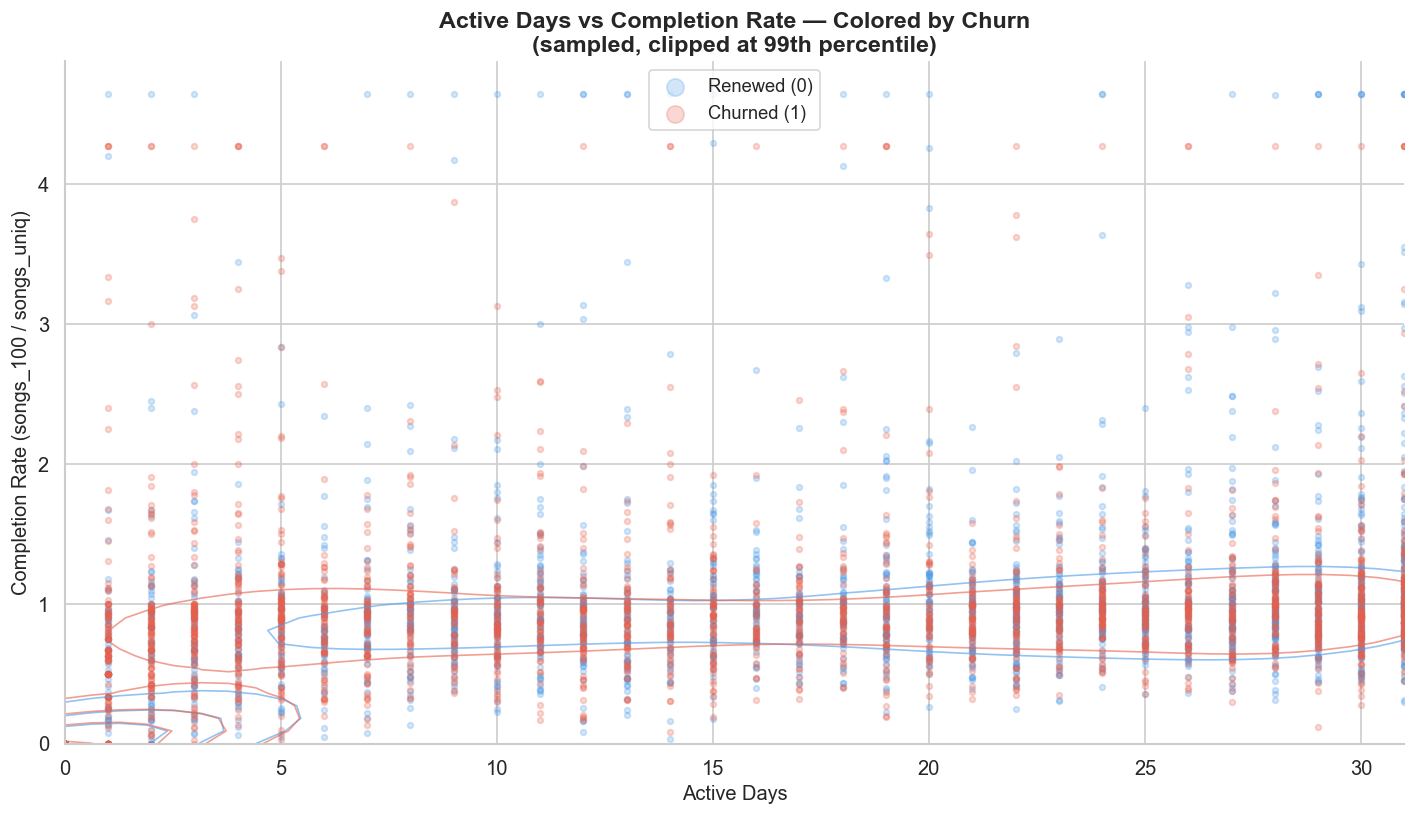

In [11]:
scatter_features = ['active_days', 'completion_rate']
scatter_features = [f for f in scatter_features if f in df.columns]

if len(scatter_features) == 2:
    fig, ax = plt.subplots(figsize=(12, 7))

    for churn_val, color in CHURN_COLORS.items():
        subset = df_sample[df_sample['is_churn'] == churn_val]
        # Clip for readability
        x = subset['active_days'].clip(0, subset['active_days'].quantile(0.99))
        y = subset['completion_rate'].clip(0, subset['completion_rate'].quantile(0.99))
        ax.scatter(x, y, c=color, alpha=0.25, s=12, label=CHURN_LABELS[churn_val])

    ax.set_xlabel('Active Days', fontsize=12)
    ax.set_ylabel('Completion Rate (songs_100 / songs_uniq)', fontsize=12)
    ax.set_title('Active Days vs Completion Rate — Colored by Churn\n(sampled, clipped at 99th percentile)',
                 fontsize=14, fontweight='bold')
    ax.legend(markerscale=3, fontsize=11)

    # Add KDE contours
    from scipy import stats as scipy_stats
    for churn_val, color in CHURN_COLORS.items():
        subset = df_sample[df_sample['is_churn'] == churn_val]
        x = subset['active_days'].clip(0, df_sample['active_days'].quantile(0.99))
        y = subset['completion_rate'].clip(0, df_sample['completion_rate'].quantile(0.99))
        try:
            values = np.vstack([x, y])
            kernel = scipy_stats.gaussian_kde(values)
            xmin, xmax = x.min(), x.max()
            ymin, ymax = y.min(), y.max()
            xx, yy = np.mgrid[xmin:xmax:50j, ymin:ymax:50j]
            positions = np.vstack([xx.ravel(), yy.ravel()])
            f = kernel(positions).reshape(xx.shape)
            ax.contour(xx, yy, f, levels=4, colors=color, linewidths=1, alpha=0.6)
        except Exception:
            pass  # skip contour if fails

    plt.tight_layout()
    plt.savefig('plot_10_scatter_engagement.png', bbox_inches='tight')
    plt.show()

---
## 11. Gender vs Churn Rate
**What to look for:**
- Note: gender has a large missing rate. The 'nan' (unknown) group is important.
- Missing gender might itself be a churn signal (users who never completed their profile).
- Males vs females: small difference expected, but worth confirming.

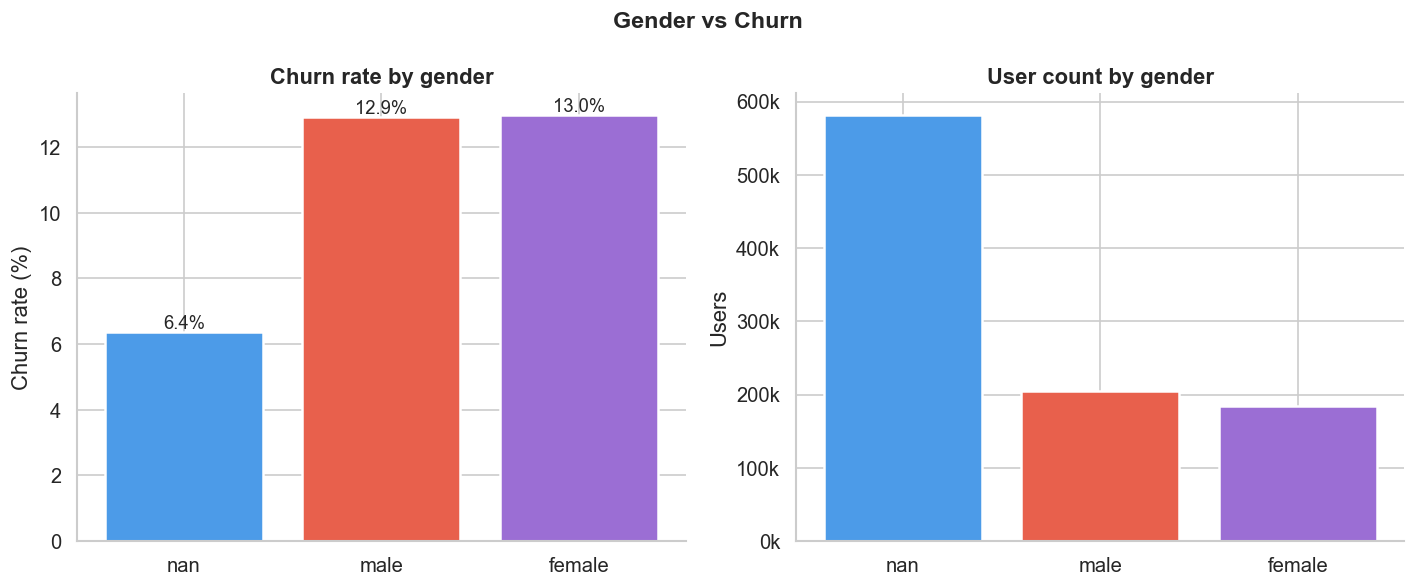

              churn_rate  user_count
gender_label                        
nan             6.355757      582055
male           12.903730      204561
female         12.986590      184344


In [12]:
gender_cols = [c for c in df.columns if c.startswith('gender_')]

if gender_cols:
    # Reconstruct gender from one-hot encoded columns
    def get_gender(row):
        for col in gender_cols:
            if row[col] == 1:
                return col.replace('gender_', '')
        return 'unknown'

    df['gender_label'] = df[gender_cols].apply(get_gender, axis=1)

    churn_by_gender = df.groupby('gender_label')['is_churn'].agg(['mean', 'count'])
    churn_by_gender.columns = ['churn_rate', 'user_count']
    churn_by_gender['churn_rate'] *= 100
    churn_by_gender = churn_by_gender.sort_values('user_count', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(churn_by_gender.index, churn_by_gender['churn_rate'],
                color=['#4C9BE8', '#E8604C', '#9B6ED4'],
                edgecolor='white', linewidth=1.5)
    for i, (idx, row) in enumerate(churn_by_gender.iterrows()):
        axes[0].text(i, row['churn_rate'] + 0.1,
                     f"{row['churn_rate']:.1f}%", ha='center', fontsize=11)
    axes[0].set_title('Churn rate by gender', fontweight='bold')
    axes[0].set_ylabel('Churn rate (%)')

    axes[1].bar(churn_by_gender.index, churn_by_gender['user_count'],
                color=['#4C9BE8', '#E8604C', '#9B6ED4'],
                edgecolor='white', linewidth=1.5)
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    axes[1].set_title('User count by gender', fontweight='bold')
    axes[1].set_ylabel('Users')

    plt.suptitle('Gender vs Churn', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_11_gender_churn.png', bbox_inches='tight')
    plt.show()
    print(churn_by_gender)

---
## 12. Feature Importance Preview — Variance-Based Ranking
**What to look for:**
- Before modeling, this shows which features have the most variance — a rough proxy for usefulness.
- Zero-variance features (constant columns) should be dropped before modeling.
- This is NOT the same as model feature importance — that comes in notebook 06.
- Think of this as a sanity check: are there features where everyone has the same value?

In [13]:
# Check for zero-variance / near-zero-variance features
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['is_churn'])
feature_variance = numeric_df.var().sort_values()

zero_var = feature_variance[feature_variance == 0]
print(f'Zero-variance features: {len(zero_var)}')
if len(zero_var) > 0:
    print(zero_var.index.tolist())

# Summary stats
print('\n--- Summary statistics ---')
core_summary = [c for c in [
    'total_secs', 'active_days', 'completion_rate',
    'avg_secs_per_day', 'last_price', 'total_cancels',
    'num_transactions', 'last_auto_renew', 'last_cancel'
] if c in df.columns]

summary = df[core_summary + ['is_churn']].groupby('is_churn').agg(['mean', 'median'])
print(summary.T.to_string())

Zero-variance features: 0

--- Summary statistics ---
is_churn                             0             1
total_secs       mean    109697.640725  97816.773264
                 median   51167.386000  38419.620000
active_days      mean        14.096925     12.326554
                 median      14.000000     10.000000
completion_rate  mean         0.832364      0.813781
                 median       0.816850      0.793651
avg_secs_per_day mean      5032.072406   5001.093488
                 median    3618.173213   3564.055722
last_price       mean       127.995035    255.358353
                 median     149.000000    149.000000
total_cancels    mean         0.015044      0.224322
                 median       0.000000      0.000000
num_transactions mean         1.152590      1.300504
                 median       1.000000      1.000000
last_auto_renew  mean         0.925868      0.372827
                 median       1.000000      0.000000
last_cancel      mean         0.005533      0

---
## EDA Summary — Key Takeaways

After running all plots, fill in what you observed:

| Feature | Observation | Impact on Model |
|---|---|---|
| `last_auto_renew` | Churners almost always have auto-renew OFF | Strongest feature — expect top importance |
| `total_secs` / `active_days` | Churners listen much less | Strong behavioral signal |
| `completion_rate` | Churners finish fewer songs | Captures disengagement |
| `total_cancels` | More cancels → much higher churn | Historical behavioral pattern |
| `last_price` | Higher price → slightly more churn | Price sensitivity signal |
| `registration_year` | Older users churn less | Loyalty effect |
| `age` | Younger users (18–25) churn more | Demographics matter |
| `gender` | Small difference, large unknown group | May not be important |

### Ready for Notebook 06 — Modeling
- Load `merged_features.csv`
- Train LightGBM with `scale_pos_weight` for class imbalance
- Target: ROC-AUC > 0.85